In [1]:
import cooperative_tasep_lib as tasep
import numpy as np
import matplotlib.pyplot as plt
import torch
from utils import Plot, CollectionPlot, MultipleExecution
import time
import sys
from joblib import Parallel, delayed

In [2]:
L = 1000
T = 100

kon=0.1
koff=1
kstep=100
kq=100

q=4

In [5]:
import logging
logging.basicConfig(filename='debug.log', level=logging.DEBUG)

In [6]:
def multiple_sims_with_logging(L, T, kon, koff, kstep, kq, q, num=100):
    RES = np.zeros((10*T+1, L, num))
    
    for i in range(num):
        try:
            data, times = tasep.sim(L, T, kon, koff, kstep, kq, q)
            # time.sleep(0.1)
            # print(data.shape)
            sys.stdout.flush()
            if data.shape != (10*T+1, L):
                logging.error(f"Shape mismatch at iteration {i}: data.shape={data.shape}, expected={(10*T+1, L)}")
                raise ValueError(f"Shape mismatch: data.shape={data.shape}, expected={(10*T+1, L)}")
            RES[:, :, i] = data
        except Exception as e:
            logging.error(f"Error at iteration {i}: {e}")
            raise

    return RES

In [10]:
DATA = multiple_sims_with_logging(1000,100,0.1,1,100,100,4, num=20)


In [3]:
class MultipleExecution:
    @staticmethod
    def same_conf_parallel(L, T, kon, koff, kstep, kq, q, num=100):
        results = Parallel(n_jobs=10, prefer="threads")(
            delayed(tasep.ssim)(L, T, kon, koff, kstep, kq, q)
            for _ in range(num)
        )
        
        return [res[0] for res in results]

In [5]:
results = Parallel(n_jobs=10, prefer="threads")(
            delayed(tasep.ssim)(L, T, kon, koff, kstep, kq, q)
            for _ in range(10)
        )

In [4]:
DATA = MultipleExecution.same_conf_parallel(1000,100,0.1,1,100,100,4, num = 10)

KeyboardInterrupt: 

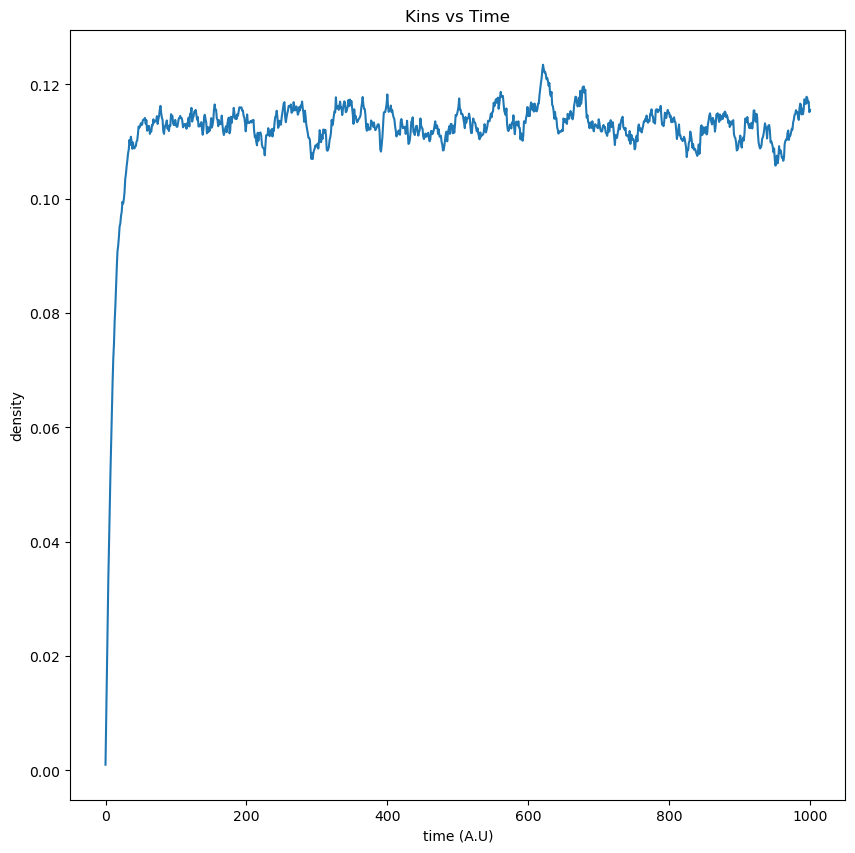

In [11]:
CollectionPlot.total_density_time(DATA)